# 02 — Dataset Generation & Inspection

Generate a reproducible dataset of sequences from a 3-state Markov chain
whose transition matrix is drawn from a symmetric Dirichlet distribution,
save it to disk, and inspect its statistical properties.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from markov_chain import (
    sample_sequences,
    sample_transition_matrix,
    stationary_distribution,
)
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Generate sequences

In [2]:
# -- Papermill parameters -----------------------------------------------------
DATA_DIR = "../data"  # output directory (string for papermill)
DGP_REGIME = "two_far"  # single | two_far | two_close
N_SEQUENCES = 10_000
MAX_SEQ_LEN = 32
SEED = 0
N_STATES = 3
ALPHA = 1.0
PAD_ID = -1
FAR_MIN_FRO = 0.5
CLOSE_MAX_FRO = 0.2
MAX_PAIR_TRIES = 10_000

In [3]:
# Parameters
DATA_DIR = "/Users/ashrafahmed/workspace/slt-deep/projects/markov-transformer/experiments/markov-chain-learning/data/single"
DGP_REGIME = "single"
SEED = 0
N_SEQUENCES = 10000
MAX_SEQ_LEN = 32

In [4]:
# -- Post-papermill coercions -------------------------------------------------
DATA_DIR = Path(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/workspace/slt-deep/projects/markov-transformer/experiments/markov-chain-learning/data/single


In [5]:
def build_transition_matrices():
    """Return (Ts, regime_info) with Ts shaped (n_chains, N_STATES, N_STATES)."""
    if DGP_REGIME == "single":
        Ts_local = sample_transition_matrix(
            n_states=N_STATES, alpha=ALPHA, n=1, rng=SEED
        )
        Ts_local = Ts_local[np.newaxis]  # (S, S) -> (1, S, S)
        info = {"n_chains": 1}
    elif DGP_REGIME == "two_far":
        for attempt in range(MAX_PAIR_TRIES):
            T2 = sample_transition_matrix(
                n_states=N_STATES, alpha=ALPHA, n=2, rng=SEED + attempt
            )
            fro = float(np.linalg.norm(T2[0] - T2[1], ord="fro"))
            if fro >= FAR_MIN_FRO:
                Ts_local = T2
                info = {"n_chains": 2, "frobenius_distance": fro}
                break
        else:
            raise RuntimeError(
                f"two_far: no pair with fro>={FAR_MIN_FRO} in {MAX_PAIR_TRIES} tries"
            )
    elif DGP_REGIME == "two_close":
        for attempt in range(MAX_PAIR_TRIES):
            T2 = sample_transition_matrix(
                n_states=N_STATES, alpha=ALPHA, n=2, rng=SEED + attempt
            )
            fro = float(np.linalg.norm(T2[0] - T2[1], ord="fro"))
            if fro <= CLOSE_MAX_FRO:
                Ts_local = T2
                info = {"n_chains": 2, "frobenius_distance": fro}
                break
        else:
            raise RuntimeError(
                f"two_close: no pair with fro<={CLOSE_MAX_FRO} in {MAX_PAIR_TRIES} tries"
            )
    else:
        raise ValueError(f"Unknown DGP_REGIME: {DGP_REGIME!r}")
    return Ts_local, info


Ts, regime_info = build_transition_matrices()
N_CHAINS = Ts.shape[0]
pis = np.stack([stationary_distribution(Ts[k]) for k in range(N_CHAINS)], axis=0)

print(f"DGP regime : {DGP_REGIME}  ({N_CHAINS} chain(s))")
print(f"Regime info: {regime_info}")
for i in range(N_CHAINS):
    print(f"\nTransition matrix T[{i}]:")
    print(np.round(Ts[i], 4))
    print(f"Stationary distribution pi[{i}]:", np.round(pis[i], 4))

DGP regime : single  (1 chain(s))
Regime info: {'n_chains': 1}

Transition matrix T[0]:
[[0.3955 0.593  0.0115]
 [0.001  0.2522 0.7468]
 [0.1587 0.1779 0.6634]]
Stationary distribution pi[0]: [0.1539 0.2612 0.5849]


In [6]:
# Sample sequences using the stationary distribution of the selected chain.

seqs_lengths = np.random.choice(np.arange(2, MAX_SEQ_LEN), N_SEQUENCES)
chain_to_sample = np.random.choice(np.arange(N_CHAINS), N_SEQUENCES)
sequences_np = np.full((N_SEQUENCES, MAX_SEQ_LEN), PAD_ID, dtype=np.int64)

for i in tqdm(range(N_SEQUENCES), desc="Sampling sequences"):
    chain_idx = chain_to_sample[i]
    seq_len = seqs_lengths[i]
    x = sample_sequences(
        Ts[chain_idx], n=1, seq_len=seq_len, prior=pis[chain_idx], rng=SEED + i
    )
    sequences_np[i, : len(x[0])] = x[0]

sequences = torch.from_numpy(sequences_np).long()

print(f"sequences: {sequences.shape}  dtype={sequences.dtype}")
print("First 10 sequences:")
print(sequences[:10])
print(f"PAD count: {(sequences == PAD_ID).sum().item():,}")

Sampling sequences:   0%|          | 0/10000 [00:00<?, ?it/s]

sequences: torch.Size([10000, 32])  dtype=torch.int64
First 10 sequences:
tensor([[ 2,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  0,  1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  2,  0,  1,  2,  2,  2,  2,  2,  0,  1,  2,  1,  2,  1,  2,  0,  1,
          1,  2,  2, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 1,  2,  2,  0,  1,  2,  1,  1,  2,  2,  2,  0,  1,  2,  2,  2,  2,  2,
          2, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 0,  0,  1,  2,  0,  1,  2,  1,  2,  0,  0,  1,  2,  2,  2,  2,  1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  2,  2,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  2,  2,  1,  1,  2,  2,  0,  0,  2,  2,  1,  2,  2, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  2,  2,  2,  2,  2,  2,  1,  2,

## Save to disk


In [7]:
save_path = DATA_DIR / "sequences.pt"

torch.save(
    {
        "sequences": sequences,
        "Ts": torch.tensor(Ts, dtype=torch.float32),
        "pis": torch.tensor(pis, dtype=torch.float32),
        "chain_to_sample": torch.tensor(chain_to_sample, dtype=torch.long),
        "seq_lengths": torch.tensor(seqs_lengths, dtype=torch.long),
        "config": {
            "N": N_SEQUENCES,
            "L": MAX_SEQ_LEN,
            "seed": SEED,
            "n_chains": N_CHAINS,
            "n_states": N_STATES,
            "alpha": ALPHA,
            "pad_id": PAD_ID,
            "dgp_regime": DGP_REGIME,
        },
    },
    save_path,
)
print(f"Saved -> {save_path}  ({save_path.stat().st_size / 1024:.1f} KB)")

Saved -> /Users/ashrafahmed/workspace/slt-deep/projects/markov-transformer/experiments/markov-chain-learning/data/single/sequences.pt  (2659.0 KB)


Per-chain empirical start probs vs stationary pi:
  chain 0: emp=[0.156 0.265 0.579]  pi=[0.154 0.261 0.585]

Overall empirical start probs: [0.156 0.265 0.579]
Overall expected (mixture):  [0.154 0.261 0.585]


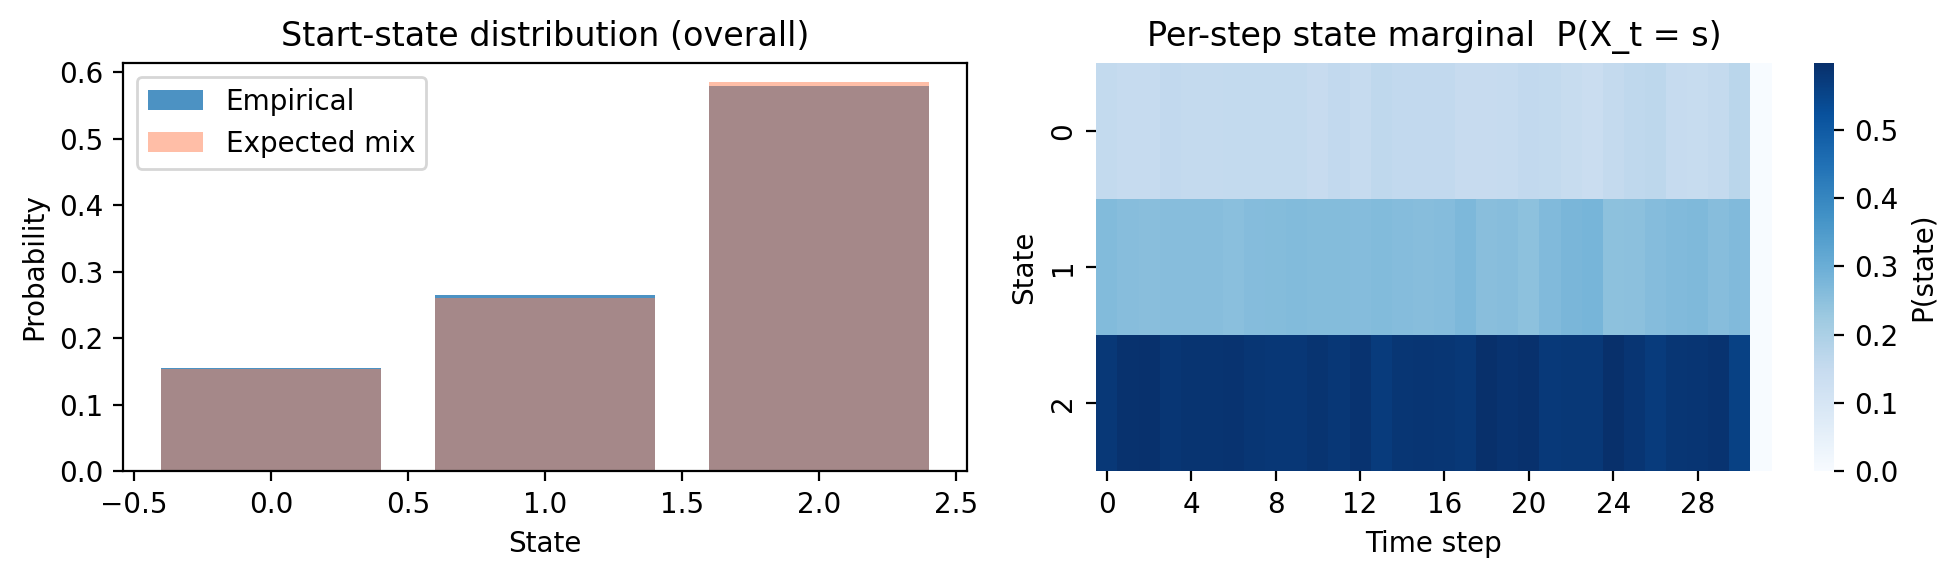

In [8]:
# Start-state verification against multiple stationary distributions.
start_tokens = sequences[:, 0]
valid_start = start_tokens != PAD_ID

chain_ids = torch.from_numpy(chain_to_sample).long()
emp_pi_by_chain = np.zeros((N_CHAINS, N_STATES), dtype=float)

for k in range(N_CHAINS):
    mask_k = valid_start & (chain_ids == k)
    if mask_k.any():
        counts_k = torch.bincount(start_tokens[mask_k], minlength=N_STATES).float()
        emp_pi_by_chain[k] = (counts_k / counts_k.sum()).numpy()

print("Per-chain empirical start probs vs stationary pi:")
for k in range(N_CHAINS):
    print(
        f"  chain {k}: emp={np.round(emp_pi_by_chain[k], 3)}  pi={np.round(pis[k], 3)}"
    )

# Aggregate expected start distribution is a mixture of chain-specific pi's.
chain_weights = np.bincount(chain_to_sample, minlength=N_CHAINS).astype(float)
chain_weights /= chain_weights.sum()
pi_mix = chain_weights @ pis

start_counts = torch.bincount(start_tokens[valid_start], minlength=N_STATES).float()
emp_mix = (start_counts / start_counts.sum()).numpy()

print("\nOverall empirical start probs:", np.round(emp_mix, 3))
print("Overall expected (mixture): ", np.round(pi_mix, 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Bar chart: overall empirical start-state vs expected mixture.
axes[0].bar(range(N_STATES), emp_mix, label="Empirical", alpha=0.8)
axes[0].bar(range(N_STATES), pi_mix, alpha=0.5, label="Expected mix", color="coral")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Probability")
axes[0].set_title("Start-state distribution (overall)")
axes[0].legend()

# Per-step state marginals (heatmap: state x time), ignoring PAD_ID tokens.
marginals = torch.zeros(N_STATES, MAX_SEQ_LEN)
for t in range(MAX_SEQ_LEN):
    token_t = sequences[:, t]
    valid_t = token_t != PAD_ID
    if valid_t.any():
        counts = torch.bincount(token_t[valid_t], minlength=N_STATES).float()
        marginals[:, t] = counts / counts.sum()

sns.heatmap(
    marginals.numpy(),
    ax=axes[1],
    cmap="Blues",
    xticklabels=4,
    yticklabels=range(N_STATES),
    cbar_kws={"label": "P(state)"},
)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("State")
axes[1].set_title("Per-step state marginal  P(X_t = s)")

plt.tight_layout()
plt.show()

## Dataset & DataLoader


In [9]:
class MarkovSequenceDataset(Dataset):
    """Wraps a (N, L) LongTensor of Markov chain sequences."""

    def __init__(self, sequences: torch.Tensor):
        self.data = sequences

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx]


dataset = MarkovSequenceDataset(sequences)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

# Sanity check: one batch
batch = next(iter(loader))
print(f"One batch: {batch.shape}  dtype={batch.dtype}")

One batch: torch.Size([256, 32])  dtype=torch.int64
